In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

In [2]:
df = pd.read_csv("out.csv", names=["a"])

In [3]:
df.head

<bound method NDFrame.head of               a
0      3.817059
1      1.105874
2      0.042274
3      1.868634
4      0.549968
...         ...
99995  1.361697
99996  0.143296
99997  1.360925
99998  0.982193
99999  2.369339

[100000 rows x 1 columns]>

(array([1.000e+00, 0.000e+00, 2.000e+00, 4.000e+00, 3.000e+00, 4.000e+00,
        1.000e+01, 5.000e+00, 1.200e+01, 2.200e+01, 1.200e+01, 2.100e+01,
        3.200e+01, 3.500e+01, 3.800e+01, 5.900e+01, 8.900e+01, 9.600e+01,
        1.150e+02, 1.600e+02, 1.910e+02, 2.370e+02, 2.940e+02, 3.510e+02,
        4.200e+02, 4.990e+02, 6.020e+02, 6.940e+02, 8.220e+02, 9.680e+02,
        1.045e+03, 1.209e+03, 1.417e+03, 1.563e+03, 1.782e+03, 1.868e+03,
        2.026e+03, 2.315e+03, 2.477e+03, 2.617e+03, 2.867e+03, 2.997e+03,
        3.018e+03, 3.166e+03, 3.247e+03, 3.440e+03, 3.445e+03, 3.459e+03,
        3.476e+03, 3.414e+03, 3.401e+03, 3.351e+03, 3.288e+03, 3.028e+03,
        2.986e+03, 2.783e+03, 2.634e+03, 2.472e+03, 2.389e+03, 2.125e+03,
        1.944e+03, 1.755e+03, 1.569e+03, 1.412e+03, 1.226e+03, 1.070e+03,
        9.670e+02, 8.240e+02, 7.770e+02, 6.180e+02, 5.290e+02, 4.070e+02,
        3.370e+02, 2.910e+02, 2.530e+02, 2.000e+02, 1.260e+02, 1.160e+02,
        1.240e+02, 8.100e+01, 6.900e+0

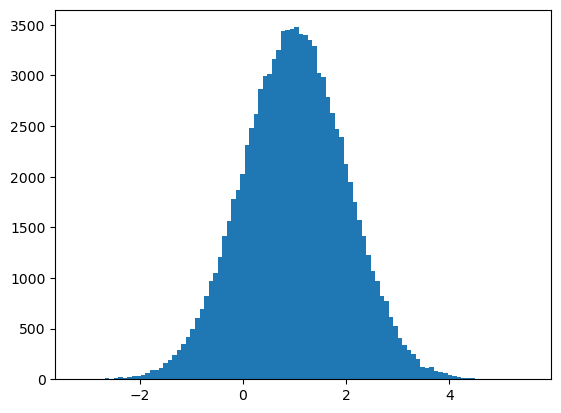

In [4]:
plt.hist(df, bins=100)

In [9]:


def loglog_hist(series: pd.Series, bins=50, **kwargs):
    """
    Plot a histogram of a pandas Series on a log-log scale with log-spaced bins.

    Parameters
    ----------
    series : pd.Series
        Input data. Only positive entries are used.
    bins : int or sequence, default=50
        If int, creates that many bins equally spaced on a logarithmic scale.
        If sequence, uses the given bin edges (assumed appropriate for log scale).
    **kwargs : additional keyword arguments
        Passed to matplotlib.pyplot.hist (e.g., alpha, color, edgecolor).

    Returns
    -------
    None
        Displays the plot.
    """
    # Drop missing values
    data = series.dropna()

    # Keep only positive values (log scale requires x > 0)
    positive_data = data[data > 0]
    if len(positive_data) < len(data):
        warnings.warn(f"Dropped {len(data) - len(positive_data)} non-positive values "
                      f"({len(positive_data)} remain)")

    if len(positive_data) == 0:
        raise ValueError("No positive data points left after filtering. Cannot plot log-log histogram.")

    # Determine bin edges
    if isinstance(bins, int):
        # Create bins equally spaced on a logarithmic scale
        log_min = np.log10(positive_data.min())
        log_max = np.log10(positive_data.max())
        bin_edges = np.logspace(log_min, log_max, bins + 1)
    else:
        # Use user-supplied bins (assumed suitable for log scale)
        bin_edges = bins

    # Plot histogram with log-spaced bins (linear counts)
    plt.hist(positive_data, bins=bin_edges, **kwargs)

    # Set both axes to logarithmic scale
    plt.xscale('log')
    plt.yscale('log')

    # Labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram (log-log scale with log-spaced bins)')

    plt.show()

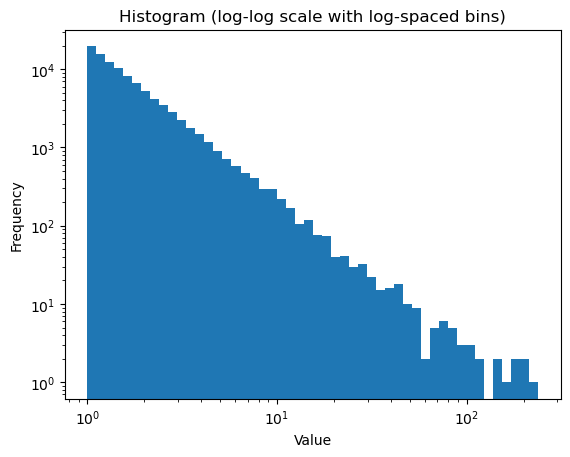

In [17]:
loglog_hist(df.a)